In [74]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_excel('PUMP PRICE PMS.xlsx')
df.head()

,Fuel Pump Price Per Litre - Average (PMS) (1960 - 2023),Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 436,Unnamed: 437,Unnamed: 438,Unnamed: 439,Unnamed: 440,Unnamed: 441,Unnamed: 442,Unnamed: 443,Unnamed: 444,Unnamed: 445
0,S/No,Descriptor,1985 January,1985 February,1985 March,1985 April,1985 May,1985 June,1985 July,1985 August,...,2021 March,2021 April,2021 May,2021 June,2021 July,2021 August,2021 September,2021 October,2021 November,2021 December
1,1,Price in Naira Per Litre,0.2,0.2,0.2,0.2,0.2,0.2,0.2,0.2,...,172.68,166.38,168.06,165.61,165.91,164.91,164.85,165.6,167.6,165.77


In [75]:
df = df.T
df = df.reset_index(drop=True)
df.head()

,0,1
0,S/No,1
1,Descriptor,Price in Naira Per Litre
2,1985 January,0.2
3,1985 February,0.2
4,1985 March,0.2


In [76]:
df.columns = df.iloc[1]
df = df[2:]
df.columns=['Date', 'Pump_Price']
df.head()

,Date,Pump_Price
2,1985 January,0.2
3,1985 February,0.2
4,1985 March,0.2
5,1985 April,0.2
6,1985 May,0.2


In [77]:
df["Date"] = pd.to_datetime(df["Date"].str.strip(), format= "%Y %B", errors = 'coerce')
df.head()

,Date,Pump_Price
2,1985-01-01,0.2
3,1985-02-01,0.2
4,1985-03-01,0.2
5,1985-04-01,0.2
6,1985-05-01,0.2


In [78]:
df.isnull().sum()

Date          0
Pump_Price    0
dtype: int64

In [79]:
df['Pump_Price'].describe()

count     444
unique     75
top        40
freq       71
Name: Pump_Price, dtype: int64

In [80]:
df = df.sort_values('Date')
df["Pump_Price"].unique()[:20]

array([0.2, 0.4, 0.42, 0.6, 0.7, 3.25, 11, 25, 20, 22, 26, 40, 70, 65,
       '141/97', 97, 87, 86.5, 145, 149.39], dtype=object)

In [82]:
def fix_price(x):
    if isinstance(x, str) and "/" in x:
        a, b = x.split("/")
        return float(a)/float(b)
    try:
        return float(x)
    except:
        return None
    
df["Pump_Price"] = df["Pump_Price"].apply(fix_price)
df['Pump_Price'].head()

2    0.2
3    0.2
4    0.2
5    0.2
6    0.2
Name: Pump_Price, dtype: float64

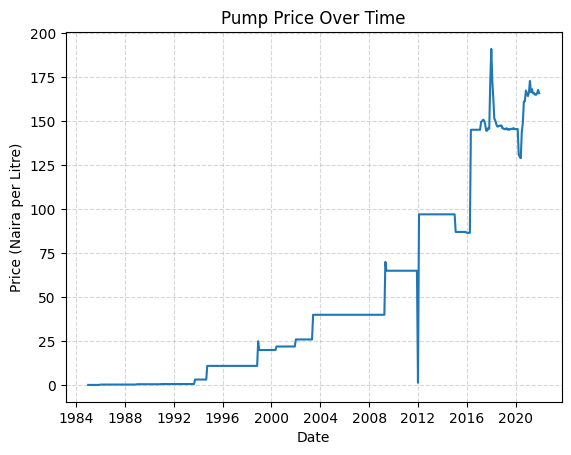

In [93]:
plt.plot(df['Date'], df['Pump_Price'])
plt.title("Pump Price Over Time")
plt.xlabel("Date")
plt.ylabel("Price (Naira per Litre)")
plt.grid(True, linestyle = "--", alpha = 0.5)
plt.show()

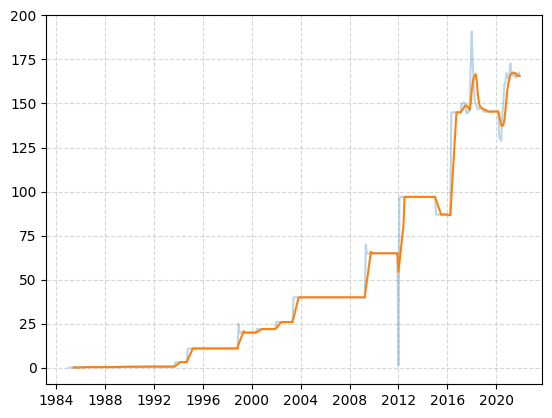

In [92]:
df['Rolling_6'] = df['Pump_Price'].rolling(window=6).mean()

plt.plot(df['Date'], df['Pump_Price'], alpha=0.3)
plt.plot(df["Date"], df["Rolling_6"])
plt.grid(True, linestyle = "--", alpha = 0.5)
plt.show()

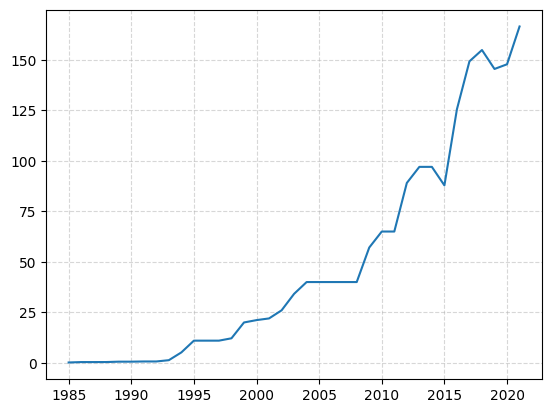

In [94]:
df["Year"] = df['Date'].dt.year
yearly = df.groupby("Year")['Pump_Price'].mean()
plt.plot(yearly.index, yearly.values)
plt.grid(True,  linestyle = "--", alpha = 0.5)
plt.show()

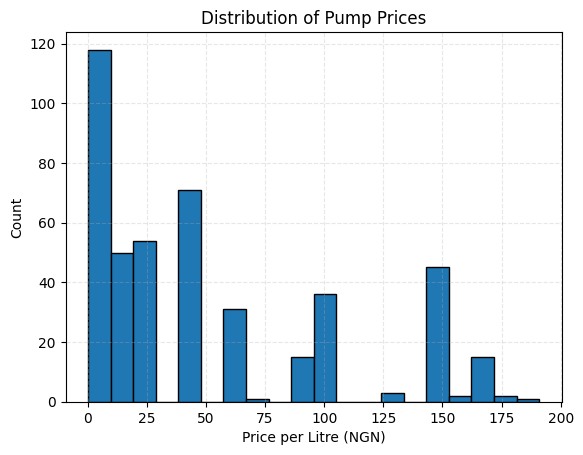

In [98]:
plt.hist(df["Pump_Price"], bins = 20, edgecolor = "black")
plt.xlabel("Price per Litre (NGN)")
plt.ylabel("Count")
plt.title("Distribution of Pump Prices")
plt.grid(True, linestyle = "--", alpha = 0.3)
plt.show()

In [91]:
df[df['Pump_Price'] > df['Pump_Price'].mean() + 2*df["Pump_Price"].std()]

,Date,Pump_Price,Rolling_6,Year
397,2017-12-01,171.79,150.090000,2017
398,2018-01-01,190.87,157.200000,2018
399,2018-02-01,172.46,161.871667,2018
400,2018-03-01,163.39,165.016667,2018
430,2020-09-01,161.06,140.476667,2020
431,2020-10-01,161.17,145.531667,2020
432,2020-11-01,167.27,151.798333,2020
433,2020-12-01,165.70,157.935000,2020
434,2021-01-01,164.09,161.345000,2021
435,2021-02-01,166.24,164.255000,2021
